### EX: Visualizing Learned Features

In this exercise, we will load a trained model and extract the intermediate activations (Feature Maps) to see the battlespace through the "eyes" of the AI.

* **Create Dummy Image:** Create a geometric shape simulating a tactical vehicle.

* **Extract Activations:** We will intercept the data as it exits the very first Convolutional layer, before it gets pooled or flattened.

* **Visualize:** Plot several of the 16 feature maps to see how different filters highlight different aspects of the target.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

/Users/mtodd/CS471/471Book/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


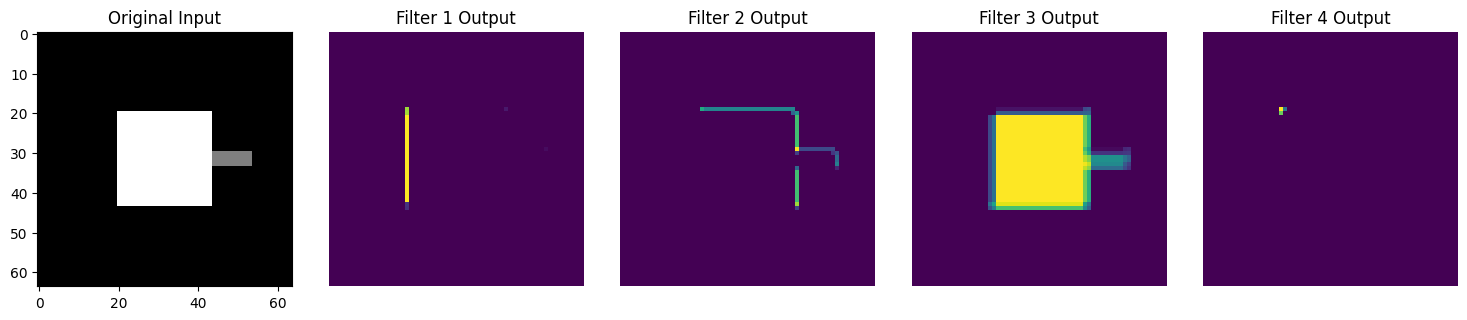

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# 1. Build the CNN Architecture using the Functional API (The Bulletproof Fix)
# This physically wires the graph together, bypassing all lazy-loading errors.
input_tensor = Input(shape=(64, 64, 3))

# Chain the layers together by passing the previous layer's output as the next layer's input
x = Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu', name='first_conv')(input_tensor)
x = MaxPooling2D(pool_size=(2, 2), strides=2)(x)
x = Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2), strides=2)(x)
x = Flatten()(x)
output_tensor = Dense(1, activation='sigmoid')(x)

# Finalize the model
model = Model(inputs=input_tensor, outputs=output_tensor)

# 2. Create a dummy image of a "Vehicle" (A square with a line)
dummy_img = np.zeros((1, 64, 64, 3))
dummy_img[0, 20:44, 20:44, :] = 1.0  # Main hull
dummy_img[0, 30:34, 44:54, :] = 0.5  # Gun barrel

# 3. Extract Intermediate Outputs
# Because we used the Functional API and named our layer, extracting it is effortless
conv_layer_output = model.get_layer('first_conv').output

# Build the extractor using our explicit inputs and the intermediate output
layer_extractor = Model(inputs=model.input, outputs=conv_layer_output)

# Extract the visual feature maps
feature_maps = layer_extractor.predict(dummy_img, verbose=0)

# 4. Visualize the Feature Maps
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(dummy_img[0])
axes[0].set_title('Original Input')

# Plot the first 4 feature maps out of the 16 available
for i in range(4):
    ax = axes[i+1]
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1} Output')
    ax.axis('off')

plt.tight_layout()
plt.show()


### Interpreting the Results

*(Note: Because our Keras model in this lab was freshly initialized and not trained on thousands of hours of ISR video, the filters are random. In a fully trained model, the results are highly deliberate).*

When you look at the Filter Outputs, you are seeing the **Spatial Hierarchy**. One filter might specifically highlight the horizontal edges of the gun barrel, glowing bright yellow while the rest of the hull fades to dark purple. Another filter might ignore the tank entirely and only highlight the sharp corners of the hull.

In a deep network, these simple edge maps are passed to the next layer, which combines them to form "treads" and "turrets." By extracting these maps, Data Scientists can mathematically prove to commanders that the AI has learned to track the physical geometry of an adversary's weapons platform, rather than relying on flawed background correlations.
